In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce') # pandas의 to_datetime 검색해서 사용법 잘 봐 두고 -  NaT (Not a Time)
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 11: 고객의 구매 시간 패턴을 분석하여 '주중 구매형', '주말 구매형', '균등 구매형'으로 분류하세요.
# 비즈니스 목적: 고객의 라이프스타일을 추정하고, '주말에 쇼핑하는 고객'에게는 금요일 저녁에 주말 쿠폰을 보내는 등 요일 타겟 프로모션의 효과를 높입니다.

###### 출력 결과를 보고 코딩하세요
``` text
고객별 구매 시간 패턴 유형:
day_type      주말   주중 shopper_type
customer_id                       
C0001        0.0  1.0       주중 구매형
C0002        0.0  1.0       주중 구매형
C0003        0.5  0.5       균등 구매형
C0004        0.0  1.0       주중 구매형
C0005        0.0  1.0       주중 구매형
```
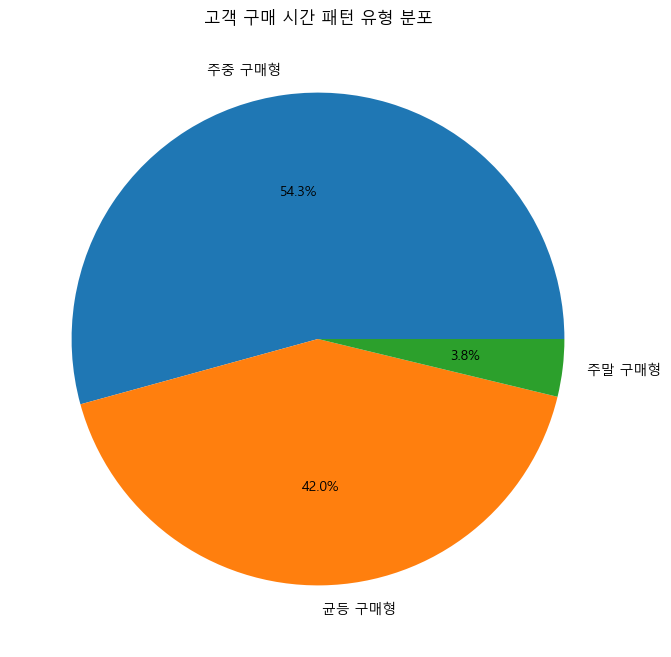

In [14]:
# 고객의 구매 시간 패턴을 분석하여 '주중 구매형', '주말 구매형', '균등 구매형'으로 분류
# 필요 컬럼 : 'customer_id', 'order_date' 
# => cutomer_id로 그룹핑하고
# order_date 에서 요일을 뽑아서 컬럼 ['weekday']에 저장하고
# 'weekday' 컬럼값 >=5 이면 주말 아니면 주중를 구분하는 컬럼 ['day_type'] 를  추가
# 고객별로 주문수량을 구한 후 각각 주중, 주말 주문비율을 구하고
# 주중, 주말 비율을 비교해서 주중 > 주말 : 주중 구매형, 주중 < 주말이면 '주말 구매형' 주중 = 주말 면 '균등 구매형' 이라고 'shoper_type' 컬럼 추가
# "고객별 구매 시간 패턴 유형:" 를 "day_type" : "주말", "주중",  "shopper_type" 컬럼으로 'customer_id'별로 출력하고
# "고객별 구매 시간 패턴 유형분포" 를 shopper_type 을 이용해 pie_chart 그리기

# 요일 구분 및 고객별 주중/주말 주문 수 집계를 한번에
# 타입 기준율
base_rate = 0.71
df_quest2B = (
    df[['customer_id', 'order_date']].copy() # 원 데이터에서 고객아이디와, 주문일자를 가져와서 
    .assign(
        weekday=lambda x: x['order_date'].dt.weekday, # 주문일자의 요일을 구한 후
        day_type=lambda x: x['weekday'].apply(lambda w: '주말' if w >= 5 else '주중') # 주중, 주말을 계산
    )
    .groupby(['customer_id', 'day_type']) # 다시 고객아이디와 day_type 별로 그룹핑한 후
    .size() # 각각를 count 하는데
    .unstack(fill_value=0) # 값이 없는 경우 0 로 채움
    .reindex(columns=['주중', '주말'], fill_value=0)  # 핵심: 두 컬럼 보장
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))  # 고객별로 sum() 구한 후, 그 값을 나눠서 비율 구하기 
    .assign(
        shopper_type=lambda x: x.apply(
            # 완전 균형
            # lambda row: '주중 구매형' if row['주중'] > row['주말'] 
            #        else '주말 구매형' if row['주중'] < row['주말']
            #        else '균등 구매형',
            lambda row: '주중 구매형' if row['주중'] >= base_rate
                   else '주말 구매형' if row['주말'] >= base_rate
                   else '균등 구매형',            
            axis=1
        )
    )
    [['주말', '주중', 'shopper_type']]  # 컬럼 순서 조정
)


고객별 구매 시간 패턴 유형:
day_type      주말   주중 shopper_type
customer_id                       
C0001        0.0  1.0       주중 구매형
C0002        0.0  1.0       주중 구매형
C0003        0.5  0.5       균등 구매형
C0004        0.0  1.0       주중 구매형
C0005        0.0  1.0       주중 구매형
shopper_type
주중 구매형    1080
균등 구매형     835
주말 구매형      75
Name: count, dtype: int64


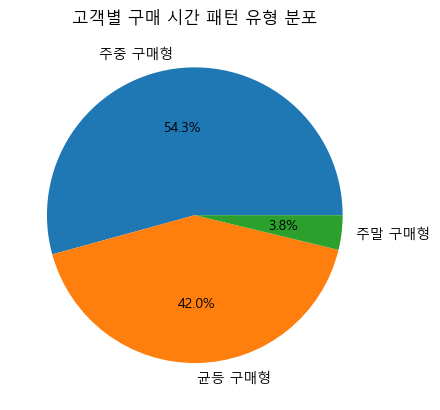

In [ ]:
# . 결과 출력
print("고객별 구매 시간 패턴 유형:")
print(df_quest2B.head())

# 5. 파이 차트
shopper_dist = df_quest2B['shopper_type'].value_counts()
print(shopper_dist)
plt.figure(figsize=(12, 6))
plt.pie(shopper_dist.values, labels=shopper_dist.index, autopct='%1.1f%%')
plt.title('고객별 구매 시간 패턴 유형 분포')
plt.show()